## Sales Analysis

### Monthly sales trend

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
main_df = pd.read_csv('../data/featured_dataset.csv')

In [12]:
# Beacuse we have duplicate orders then plot will be mislead
orders_df = main_df.drop_duplicates(subset="order_id")

main_df['order_purchase_timestamp'] = pd.to_datetime(
    main_df['order_purchase_timestamp'],
    errors='coerce'
)

# Then group by purchase month and sum total_payment_value
monthly_sales = (
    orders_df
    .groupby(orders_df["order_purchase_timestamp"].dt.to_period("M"))["total_payment_value"]
    .sum()
)
monthly_sales

order_purchase_timestamp
2016-09        252.24
2016-10      58863.52
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194599.11
2017-12     878134.67
2018-01    1115004.18
2018-02     992325.74
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: total_payment_value, dtype: float64

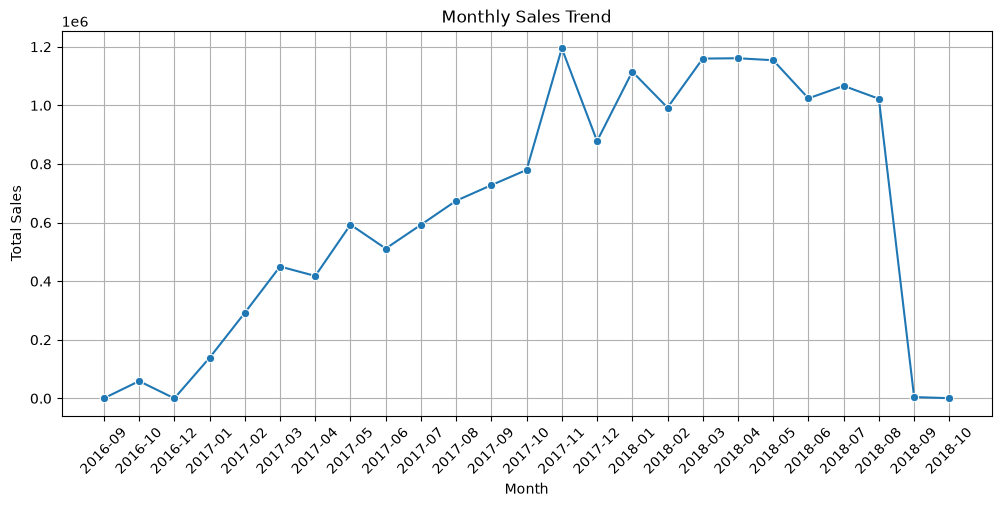

In [13]:
# Changing index to string for x-axis
monthly_sales.index = monthly_sales.index.astype(str)

# Creating figure with specific size
plt.figure(figsize=(12, 5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

In [ ]:
# Checking the last 2 months drop
orders_df.groupby(
    orders_df["order_purchase_timestamp"].dt.to_period("M")
)["order_id"].nunique()

order_purchase_timestamp
2016-09       4
2016-10     321
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7542
2017-12    5671
2018-01    7269
2018-02    6727
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

### Revenue by Category

In [18]:
revenue_by_category = pd.DataFrame(main_df.groupby(main_df['product_category_name'])['price'].sum())

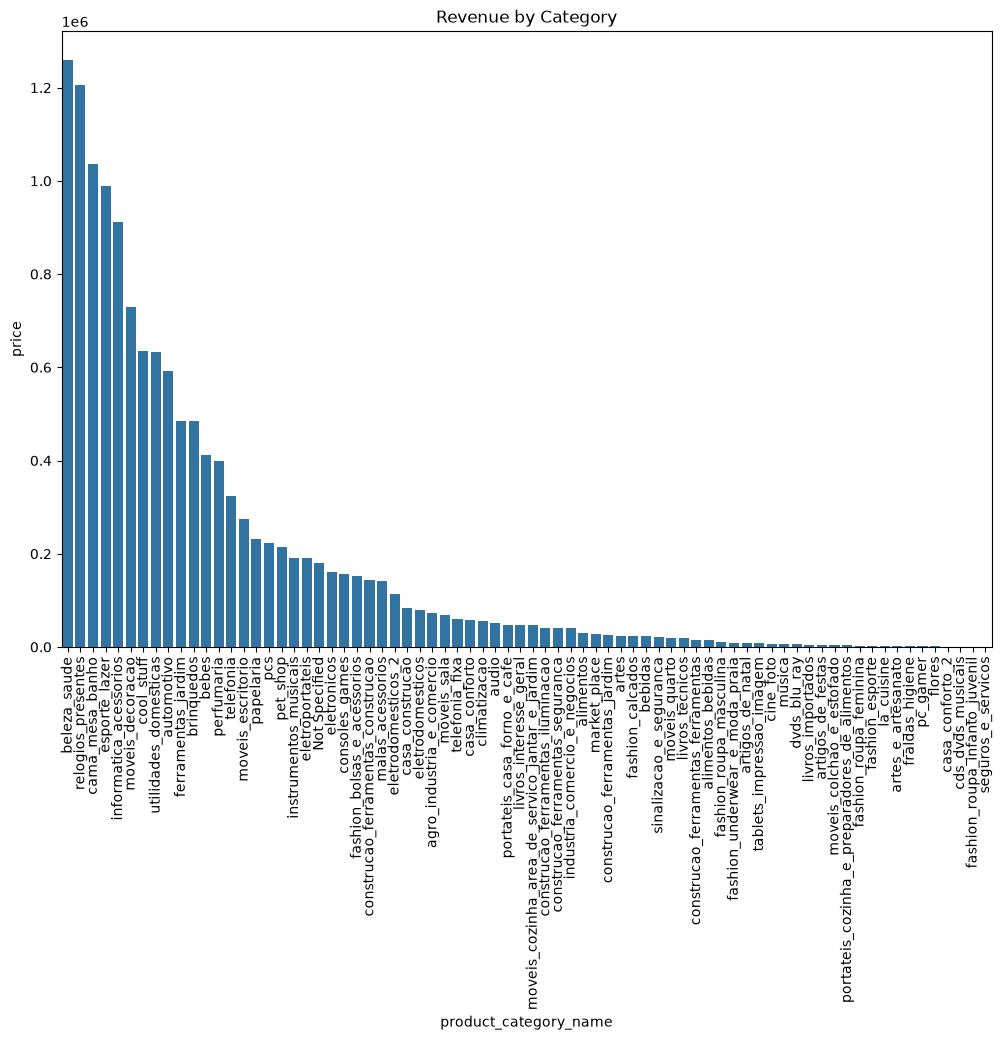

In [24]:
revenue_by_category = revenue_by_category.reset_index()
revenue_by_category = revenue_by_category[['product_category_name','price']].sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=revenue_by_category,
    x='product_category_name',
    y='price'
)
plt.title("Revenue by Category")
plt.xticks(rotation=90)
plt.show()

### Revenue by State

In [27]:
revenue_by_state = pd.DataFrame(main_df.groupby(main_df['seller_state'])['price'].sum())

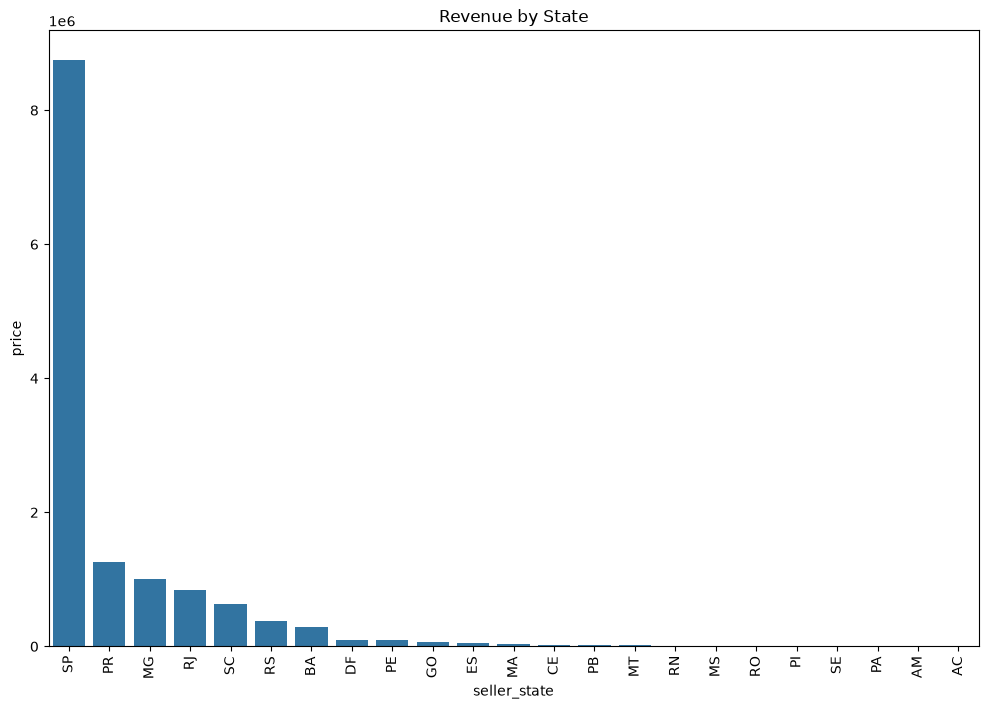

In [29]:
revenue_by_state = revenue_by_state.reset_index()
revenue_by_state = revenue_by_state[['seller_state','price']].sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=revenue_by_state,
    x='seller_state',
    y='price'
)
plt.title("Revenue by State")
plt.xticks(rotation=90)
plt.show()

### Average order value

In [38]:
main_df.groupby('order_id')[['price', 'freight_value']].sum()

,price,freight_value
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
00018f77f2f0320c557190d7a144bdd3,239.90,19.93
000229ec398224ef6ca0657da4fc703e,199.00,17.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14
...,...,...
fffc94f6ce00a00581880bf54a75a037,299.99,43.41
fffcd46ef2263f404302a634eb57f7eb,350.00,36.53
fffce4705a9662cd70adb13d4a31832d,99.90,16.95
